In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy.special import jn
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter

#import jcamp as jc

In [12]:


# Load the file. We use allow_pickle=True because it contains a Python dictionary.
# The .item() extracts the dictionary from the 0-D numpy array it gets wrapped in.
data = np.load('processed_data/urban/urban_processed_data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 1. Let's check X just to be sure it IS an array
print("Type of X:", type(data['X']))
if hasattr(data['X'], 'shape'):
    print("Shape of X:", data['X'].shape)

# 2. Let's peek inside the dictionary 'A'
print("\nType of A:", type(data['A']))
if isinstance(data['A'], dict):
    print("Keys inside A:", data['A'].keys())

# 3. Let's peek inside the dictionary 'S'
print("\nType of S:", type(data['S']))
if isinstance(data['S'], dict):
    print("Keys inside S:", data['S'].keys())

# 3. (Optional) Look at a small slice of the actual numbers
#print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (162, 94249)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])


In [ ]:
A_list= data['A']
S_list = data['S']
X = data['X']


S_gt = S_list['S_ref']
A_gt = A_list['A_ref']


print(S_gt.shape)
print(A_gt.shape)

(162, 4)
(4, 94249)


In [11]:
# Load the file. We use allow_pickle=True because it contains a Python dictionary.
# The .item() extracts the dictionary from the 0-D numpy array it gets wrapped in.
data = np.load('processed_data\jasper\data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
#print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (100, 100, 198)
Shape of A_gt (Abundance Map): (4, 10000)
Shape of S_gt (Endmember Spectra): (198, 4)


(10, 1000, 30)
(30, 2)
(2, 10000)
[[0.18873628 0.77444005 0.57459677 ... 0.42973545 0.3449533  0.01702569]
 [0.81126372 0.22555995 0.42540323 ... 0.57026455 0.6550467  0.98297431]]


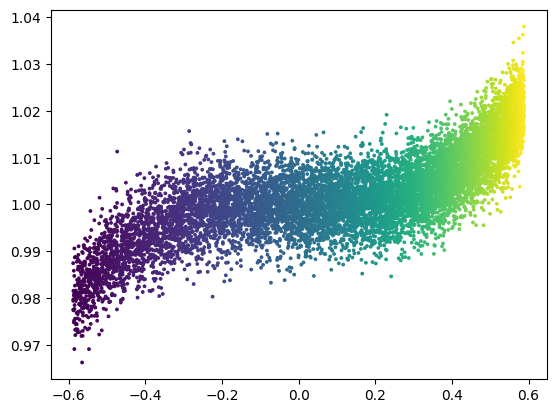

In [67]:
num_points = 10000
h=10
error_std = 0.005
power = 3
start_end = 1.7
fl = 10
dims = 30


labels =  np.random.uniform(low=1/np.exp(1/start_end), high=np.exp(1/start_end), size=num_points)
s_l = 1/np.exp(1/start_end)
e_l = np.exp(1/start_end)
true = [s_l,e_l]

colors =( labels - np.min(labels))/(np.max(labels) - np.min(labels)+0.01)+0.005

noise = np.random.normal(loc=0.0, scale=error_std, size=labels.shape)
X_data = np.log(labels) 
x_true = np.log(true)
Y_data_pure = 1/fl*np.power(X_data,power)+1
y_true = 1/fl*np.power(x_true,power)+1
Y_data = Y_data_pure + noise
plt.scatter(X_data, Y_data, s= 3, c = colors)

embedding_mat = np.abs(np.random.normal(loc = 12, scale = 0.5, size =(dims,2) ))+0.00001

raw_data = embedding_mat @ [X_data, Y_data]



end_members = embedding_mat@[x_true,y_true]


label_mat = np.abs([colors, 1-colors])

data_min = np.min(raw_data)
data_max = np.max(raw_data)

# Scale both the raw data and the ground truth spectra identically
raw_data = (raw_data - data_min) / (data_max - data_min)
end_members = (end_members - data_min) / (data_max - data_min)

data_mat = raw_data.T.reshape(h,(int) (num_points/h), dims)

print(data_mat.shape)
print(end_members.shape)
print(label_mat.shape)
print(label_mat)


In [68]:
A_gt = label_mat
S_gt = end_members
custom_dataset = {
    'X': data_mat,
    'A_gt': A_gt,
    'S_gt': S_gt
}
np.save('my_custom_dataset.npy', custom_dataset)

In [69]:
data = np.load('my_custom_dataset.npy', allow_pickle=True).item()

# 1. See what keys are inside
# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (10, 1000, 30)
Shape of A_gt (Abundance Map): (2, 10000)
Shape of S_gt (Endmember Spectra): (30, 2)

First pixel's spectra in X:
 [0.38022342 0.34404713 0.33033329 0.42294024 0.32920556 0.32623032
 0.35296222 0.27131364 0.37532729 0.3745024  0.33147728 0.32895591
 0.35580486 0.36965394 0.3738868  0.29798626 0.27208358 0.32225317
 0.3362095  0.37110249 0.31265581 0.29825903 0.3467204  0.28629715
 0.32564488 0.32728013 0.3168774  0.33299921 0.36125781 0.35018433]


ModuleNotFoundError: No module named 'nbformat'

In [ ]:
data = np.load('processed_data\jasper\jasper_processed_data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())